## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## Load Clean Data

In [3]:
df = pd.read_csv('../data/processed/credit_clean.csv')

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

print(f"Features: {X.shape[1]}")
print(f"Default rate: {y.mean():.2%}")

Features: 10
Default rate: 6.05%


## Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 89628 rows
Test:  22407 rows


## Preprocessing Pipeline

In [5]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_proc = pipeline.fit_transform(X_train)
X_test_proc = pipeline.transform(X_test)

## Train Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, scale_pos_weight=14,
        random_state=42, n_jobs=-1, eval_metric='auc'
    )
}

results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train_proc, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    results[name] = scores.mean()
    print(f"{name}: AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: AUC = 0.7952 ± 0.0058
Random Forest: AUC = 0.8123 ± 0.0058
XGBoost: AUC = 0.8438 ± 0.0048


## ROC Curves

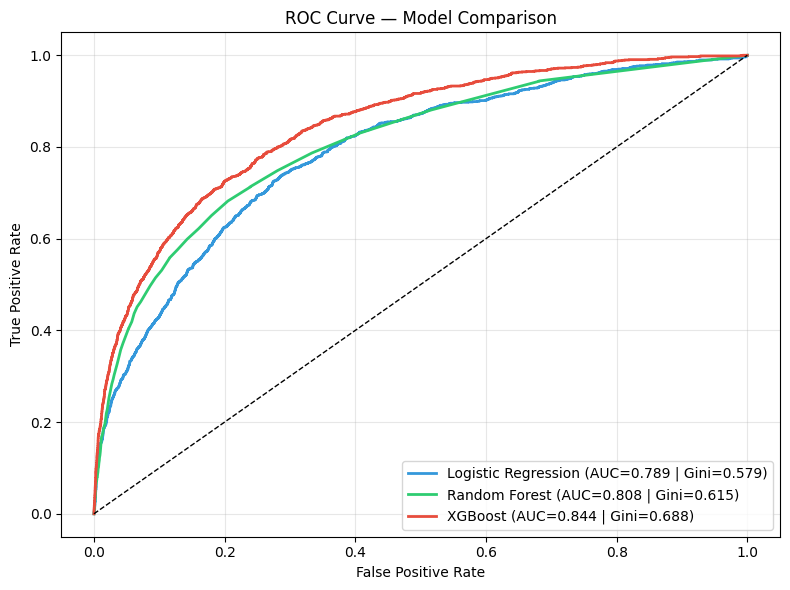

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498DB', '#2ECC71', '#E74C3C']

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train_proc, y_train)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f} | Gini={gini:.3f})',
            lw=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()

## Best Model Report

In [8]:
# Use XGBoost as final model
best_model = models['XGBoost']
y_pred = best_model.predict(X_test_proc)
y_prob = best_model.predict_proba(X_test_proc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

print(f"{'='*45}")
print(f"  Final Model: XGBoost")
print(f"{'='*45}")
print(f"  AUC-ROC : {auc:.4f}")
print(f"  Gini    : {gini:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

  Final Model: XGBoost
  AUC-ROC : 0.8440
  Gini    : 0.6880

              precision    recall  f1-score   support

           0       0.98      0.81      0.89     21051
           1       0.19      0.71      0.30      1356

    accuracy                           0.80     22407
   macro avg       0.59      0.76      0.59     22407
weighted avg       0.93      0.80      0.85     22407



## Feature Importance

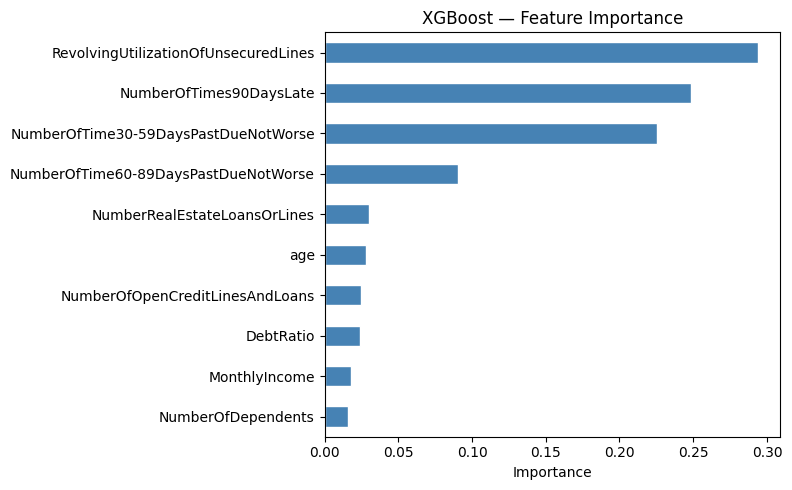

In [9]:
feat_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()